In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
df = pd.read_csv("Raisin_Dataset.csv")

In [31]:
df

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen
...,...,...,...,...,...,...,...,...
895,83248,430.077308,247.838695,0.817263,85839,0.668793,1129.072,Besni
896,87350,440.735698,259.293149,0.808629,90899,0.636476,1214.252,Besni
897,99657,431.706981,298.837323,0.721684,106264,0.741099,1292.828,Besni
898,93523,476.344094,254.176054,0.845739,97653,0.658798,1258.548,Besni


In [32]:
df.describe()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,87804.127778,430.929950,254.488133,0.781542,91186.090000,0.699508,1165.906636
std,39002.111390,116.035121,49.988902,0.090318,40769.290132,0.053468,273.764315
min,25387.000000,225.629541,143.710872,0.348730,26139.000000,0.379856,619.074000
25%,59348.000000,345.442898,219.111126,0.741766,61513.250000,0.670869,966.410750
50%,78902.000000,407.803951,247.848409,0.798846,81651.000000,0.707367,1119.509000
75%,105028.250000,494.187014,279.888575,0.842571,108375.750000,0.734991,1308.389750
max,235047.000000,997.291941,492.275279,0.962124,278217.000000,0.835455,2697.753000


In [33]:
print(df.columns)

Index(['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity',
       'ConvexArea', 'Extent', 'Perimeter', 'Class'],
      dtype='object')


In [34]:
print(df.isnull().sum())

Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
Extent             0
Perimeter          0
Class              0
dtype: int64


In [21]:
X = df.drop(columns="Class")

In [22]:
X

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251
...,...,...,...,...,...,...,...
895,83248,430.077308,247.838695,0.817263,85839,0.668793,1129.072
896,87350,440.735698,259.293149,0.808629,90899,0.636476,1214.252
897,99657,431.706981,298.837323,0.721684,106264,0.741099,1292.828
898,93523,476.344094,254.176054,0.845739,97653,0.658798,1258.548


In [23]:
Y = df["Class"]

In [24]:
Y

0      Kecimen
1      Kecimen
2      Kecimen
3      Kecimen
4      Kecimen
        ...   
895      Besni
896      Besni
897      Besni
898      Besni
899      Besni
Name: Class, Length: 900, dtype: object

There are 2 classes Kecimen and Besni which are 2 types of Raisins they are being categoried into 2 classes that is their type bases upon their characteristics such as area perimeter and etc.

In [41]:
class NearestNeighborClassifierManual:
    def __init__(self):
        self.X_train = None
        self.y_train = None

    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    def predict(self, X_test):
        predictions = []
        for x_test in X_test:
            distances = np.linalg.norm(self.X_train - x_test, axis=1)
            nearest_neighbor_index = np.argmin(distances)
            predictions.append(self.y_train[nearest_neighbor_index])
        return predictions

In [48]:
from sklearn.neighbors import KNeighborsClassifier

k = 2

knn_model = KNeighborsClassifier(n_neighbors=k)
knn_model.fit(X, np.zeros_like(X))

distances, indices = knn_model.kneighbors(X)

raisin_radii = np.max(distances, axis=1)

ValueError: too many values to unpack (expected 2)

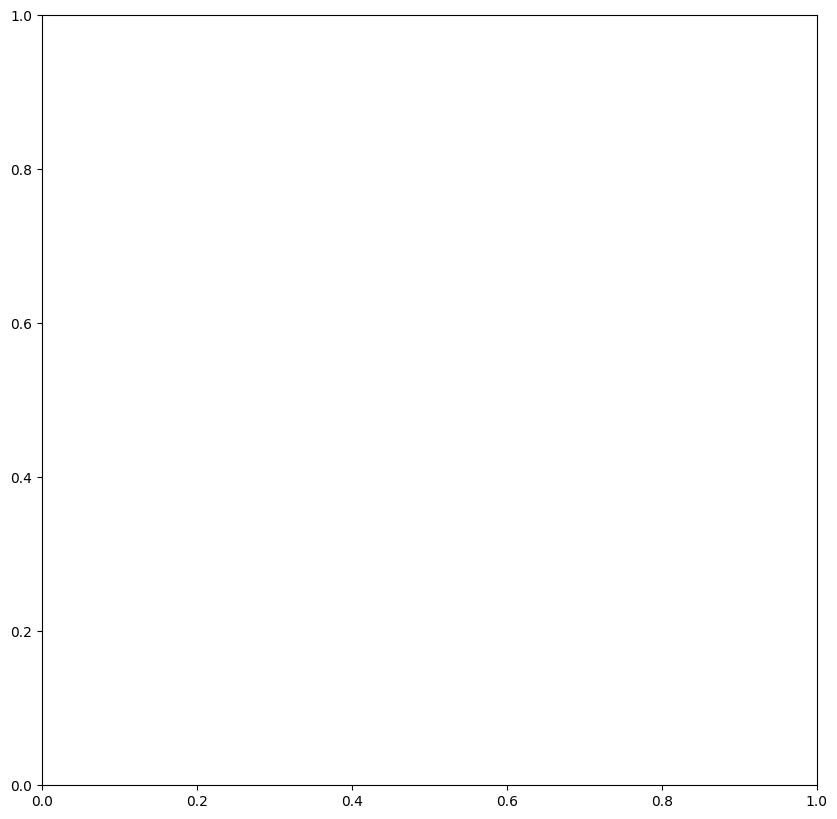

In [45]:
fig, ax = plt.subplots(figsize=(10, 10))

for i, (x, y) in enumerate(X):
    circle = plt.Circle((x, y), raisin_radii[i], color='red', alpha=0.3)
    ax.add_artist(circle)

ax.legend()

plt.show()

In [47]:
num_clusters = len(raisin_radii)
print("Number of clusters found:", num_clusters)

NameError: name 'raisin_radii' is not defined

In [ ]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.cm as cm

random_points = np.column_stack((X, Y))

k = 2

knn_model = NearestNeighbors(n_neighbors=k)
knn_model.fit(X)

distances, indices = knn_model.kneighbors(X)

raisin_radii = distances.flatten()

fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(X, Y, color='blue', label='Random Points')

for i, (x, y) in enumerate(random_points):
    circle = plt.Circle((x, y), raisin_radii[i], color=cm.Blues(raisin_radii[i] / np.max(raisin_radii)), alpha=0.5)
    ax.add_artist(circle)

ax.legend()

plt.show()
